In [4]:
using Plots
using LinearAlgebra
using Krylov
using Printf
using LaTeXStrings
using BenchmarkTools
include("poisson2d.jl")

assemble_laplacian2d (generic function with 1 method)

In [5]:
default(lw=2, markersize=6,
    xtickfont=font(12), ytickfont=font(12),
    guidefont=font(14), legendfont=font(12), titlefont=font(12))

# Poisson Equation Example
Solve
$$
-\Delta u = f
$$
over $(0,L_x)\times (0,L_y)$ with zero Dirichlet boundary conditions.

Test with the eigenfunctions
$$
u = \sin(k_x \pi/L_x x)\sin(k_y \pi y/L_y)
$$
where $k_x,k_y\in \mathbb{Z}$, since these satisfy the boudnary conditions and
$$
-\Delta u = [(k_x \pi/L_x)^2 + (k_y\pi/L_y)^2] u
$$

In [6]:
Lx = 1;
Ly = 1;
nx = 19; # (nx-1)×(ny-1) interior points
ny = 19;

x = LinRange(0, Lx, nx + 2)
y = LinRange(0, Ly, ny + 2)

@show Δx = x[2] - x[1];
@show Δy = y[2] - y[1];


xy = [[x_, y_] for x_ in x, y_ in y]; # mesh including boundary points
xy_int = [[x_, y_] for x_ in x[2:end-1],y_ in y[2:end-1]]; # interior mesh points

Δx = x[2] - x[1] = 0.05
Δy = y[2] - y[1] = 0.05


In [7]:
A = assemble_laplacian2d(Δx, Δy, nx, ny);

In [8]:
A

361×361 SparseMatrixCSC{Float64, Int64} with 1729 stored entries:
⎡⠻⣦⡙⢤⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠓⣌⠻⣦⡙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠳⣌⠻⣦⡙⢆⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠈⠳⢌⠱⣦⡑⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠈⠱⣌⠱⣦⡙⢦⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠈⠳⣌⠻⣦⡙⢤⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠓⣌⠻⣦⡙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣌⠻⣦⡑⢆⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠱⢌⠻⣦⡙⢦⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣌⠛⣤⡙⢤⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠓⣌⠛⣤⡙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣌⠻⣦⡑⢆⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠱⢌⠻⣦⡙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣌⠻⣦⡙⢤⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠓⣌⠻⣦⡙⢦⡀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠳⣌⠻⢆⡙⢆⡀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⢌⠻⢆⡑⢦⡀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠱⣌⠻⣦⡙⢦⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣌⠻⣦⡙⢤⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠓⣌⠻⣦⎦

In [9]:
fldmod1(50, nx)

(3, 12)

In [10]:
nx*(3-1) + 12

50

In [11]:
kx = 3;
ky = 2;
# X = (x,y) in 2D
u_exact = X -> sin(kx * π * X[1] / Lx) * sin(ky * π * X[2] / Ly);
f = X -> ((kx * π / Lx)^2 + (ky * π / Ly)^2) * u_exact(X);

In [12]:
B = f.(xy_int)[:]; # flattern into a column vector

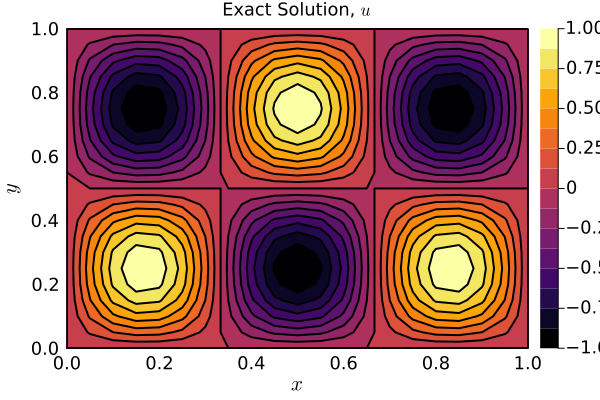

In [13]:
contourf(x, y, u_exact.(xy)')# note use of transpose;
xlabel!(L"$x$")
ylabel!(L"$y$")
title!(L"Exact Solution, $u$")

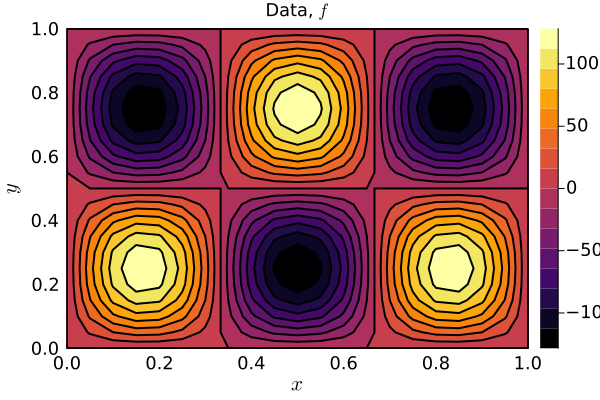

In [14]:
contourf(x, y, f.(xy)')# note use of transpose;
xlabel!(L"$x$")
ylabel!(L"$y$")
title!(L"Data, $f$")

In [15]:
U = A \ B;
u = reshape(U, nx, ny); # get as a 2D array

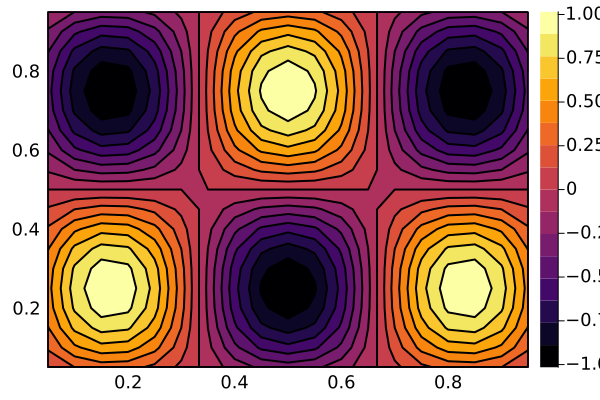

In [16]:
contourf(x[2:end-1], y[2:end-1], u')

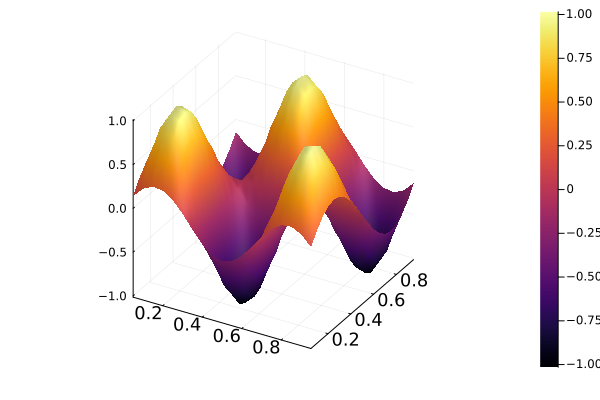

In [17]:
surface(x[2:end-1], y[2:end-1], u')

In [18]:
err = norm(U .- u_exact.(xy_int)[:], Inf);
println("Error = ", err)

Error = 0.015475237770222527


# Timing and Error

In [19]:
function poisson_solve(n, kx=1, ky=1)
    Lx = 1
    Ly = 1
    nx = n 
    ny = n
    x = LinRange(0, Lx, nx + 2)
    y = LinRange(0, Ly, ny + 2)

    Δx = x[2] - x[1]
    Δy = y[2] - y[1]

    kx = 1
    ky = 1
    u_exact = X -> sin(kx * π * X[1] / Lx) * sin(ky * π * X[2] / Ly)
    f = X -> ((kx * π / Lx)^2 + (ky * π / Ly)^2) * sin(kx * π * X[1] / Lx) * sin(ky * π * X[2] / Ly)
    xy_int = [[x_, y_] for x_ in x[2:end-1],y_ in y[2:end-1]]; # interior mesh points
    B = f.(xy_int)[:] # flattern into a column vector
    A = assemble_laplacian2d(Δx, Δy, nx, ny)
    U = A \ B
    err = norm(U .- u_exact.(xy_int)[:], Inf)
    return err
end

poisson_solve (generic function with 3 methods)

In [20]:
n_vals = [10, 20, 40, 80, 160, 320];
for n in n_vals
    @btime poisson_solve($n);
end

  66.000 μs (740 allocations: 229.19 KiB)
  383.167 μs (2567 allocations: 987.48 KiB)
  1.674 ms (9781 allocations: 3.68 MiB)
  7.366 ms (38593 allocations: 15.31 MiB)
  37.501 ms (153805 allocations: 62.01 MiB)
  200.514 ms (614616 allocations: 253.39 MiB)


In [21]:
function poisson_solve_krylov(n, kx=1, ky=1)
    Lx = 1
    Ly = 1
    nx = n
    ny = n
    x = LinRange(0, Lx, nx + 2)
    y = LinRange(0, Ly, ny + 2)

    Δx = x[2] - x[1]
    Δy = y[2] - y[1]

    kx = 1
    ky = 1
    u_exact = X -> sin(kx * π * X[1] / Lx) * sin(ky * π * X[2] / Ly)
    f = X -> ((kx * π / Lx)^2 + (ky * π / Ly)^2) * sin(kx * π * X[1] / Lx) * sin(ky * π * X[2] / Ly)
    xy_int = [[x_, y_] for x_ in x[2:end-1],y_ in y[2:end-1]]; # interior mesh points
    B = f.(xy_int)[:] # flattern into a column vector
    A = assemble_laplacian2d(Δx, Δy, nx, ny)
    U, _= cg(A, B)
    err = norm(U .- u_exact.(xy_int)[:], Inf)
    return err
end

poisson_solve_krylov (generic function with 3 methods)

In [ ]:
n_vals = [10, 20, 40, 80, 160, 320];
for n in n_vals
    @btime poisson_solve_krylov($n)
end

In [ ]:
err_vals = Float64[];
for n in n_vals
    push!(err_vals, poisson_solve(n))
end

In [ ]:
scatter(1 ./ n_vals, err_vals, 
    xscale=:log10, yscale=:log10, label="Error")
plot!(1 ./ n_vals, 1 ./ n_vals .^ 2, 
    label=L"$\propto \Delta x^2$")
xlabel!(L"$\Delta x$")